# Data Ipinyou

## Tạo bộ dữ liệu

In [1]:
import pandas as pd

df = pd.read_csv(
    "all/train.log.txt",
    sep="\t",
    dtype=str
)

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
# df.describe()

In [4]:
# df.tail()

In [5]:
cols = [
    'hour',
    'region',
    'city',
    'slotwidth',
    'slotheight',
    'slotvisibility',
    'slotformat',   
    'bidprice',
    'timestamp'
]


df = df[cols]

In [6]:
df_june = df[df['timestamp'].str.startswith('20130607')]

In [7]:
df_june.describe()

,hour,region,city,slotwidth,slotheight,slotvisibility,slotformat,bidprice,timestamp
count,1805953,1805953,1805953,1805953,1805953,1805953,1805953,1805953,1805953
unique,24,35,370,13,7,4,3,6,1616043
top,00,216,1,300,250,0,0,300,20130607000117278
freq,116901,201029,94405,682129,765791,968857,1304106,922300,13


In [8]:
drop_cols = ['timestamp']

df_june.drop(drop_cols, axis=1, inplace=True)

In [9]:
# df_june.count()

In [10]:
# df_june.to_csv('train_data.csv', index=False)

## Tiền xử lý

In [11]:
df = df_june

In [12]:
df.describe()

,hour,region,city,slotwidth,slotheight,slotvisibility,slotformat,bidprice
count,1805953,1805953,1805953,1805953,1805953,1805953,1805953,1805953
unique,24,35,370,13,7,4,3,6
top,00,216,1,300,250,0,0,300
freq,116901,201029,94405,682129,765791,968857,1304106,922300


In [13]:
df.head()

,hour,region,city,slotwidth,slotheight,slotvisibility,slotformat,bidprice
1821350,00,65,75,728,90,2,0,238
1821351,00,94,96,160,600,2,0,300
1821352,00,65,73,300,250,2,1,227
1821353,00,40,42,300,250,2,1,300
1821354,00,55,56,336,280,2,1,300


In [14]:
df.dtypes

hour              str
region            str
city              str
slotwidth         str
slotheight        str
slotvisibility    str
slotformat        str
bidprice          str
dtype: object

In [15]:
from sklearn.preprocessing import MinMaxScaler

cat_cols = ['hour', 'region', 'city', 'slotwidth', 'slotheight', 'slotvisibility', 'slotformat']

scaler = MinMaxScaler(feature_range=(0, 1))
df[cat_cols] = scaler.fit_transform(df[cat_cols])

# Convert bool → int
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)
df['bidprice'] = df['bidprice'].astype(float)

In [16]:
df.describe()

,hour,region,city,slotwidth,slotheight,slotvisibility,slotformat,bidprice
count,1.805953e+06,1.805953e+06,1.805953e+06,1.805953e+06,1.805953e+06,1.805953e+06,1.805953e+06,1.805953e+06
mean,5.841450e-01,3.665535e-01,3.749291e-01,4.340644e-01,2.770728e-01,1.120902e-02,6.036292e-02,2.709369e+02
std,2.718210e-01,2.655699e-01,2.658373e-01,3.316826e-01,2.324504e-01,8.972424e-02,1.149559e-01,3.030769e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.270000e+02
25%,4.347826e-01,1.645570e-01,1.779449e-01,2.045455e-01,5.555556e-02,0.000000e+00,0.000000e+00,2.380000e+02
50%,6.086957e-01,3.392405e-01,3.634085e-01,2.045455e-01,3.518519e-01,0.000000e+00,0.000000e+00,3.000000e+02
75%,7.826087e-01,5.468354e-01,5.538847e-01,6.909091e-01,3.518519e-01,7.843137e-03,2.000000e-01,3.000000e+02
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+02


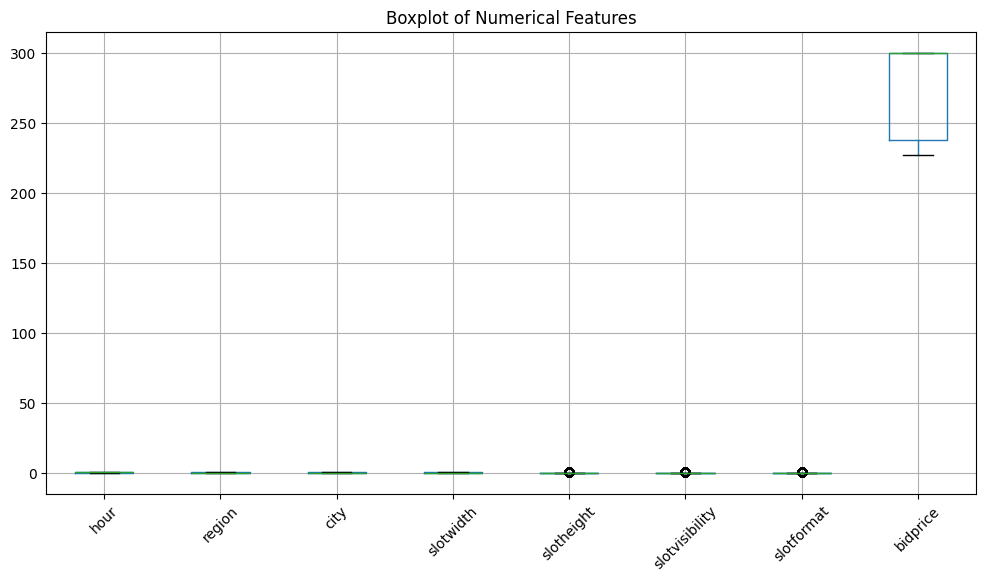

In [17]:
import matplotlib.pyplot as plt

num_cols = [
    'hour', 'region', 'city',
    'slotwidth', 'slotheight',
    'slotvisibility', 'slotformat',
    'bidprice'
]

plt.figure(figsize=(12, 6))
df[num_cols].boxplot()

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [18]:
# from sklearn.preprocessing import StandardScaler

# num_cols = [
#     'hour', 'region', 'city',
#     'slotwidth', 'slotheight',
#     'slotvisibility', 'slotformat',
#     'bidprice'
# ]

# scaler = StandardScaler()
# df[num_cols] = scaler.fit_transform(df[num_cols])

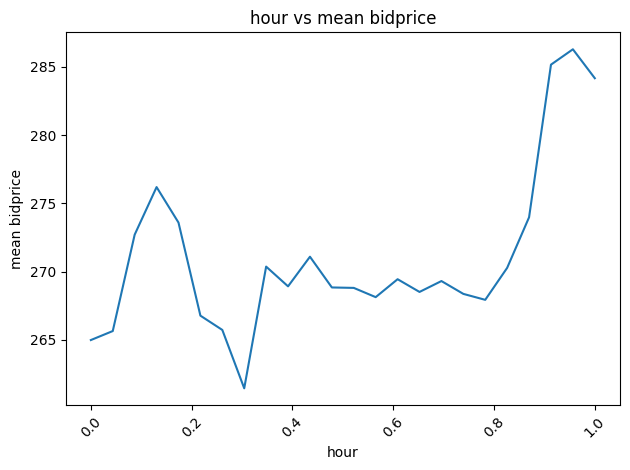

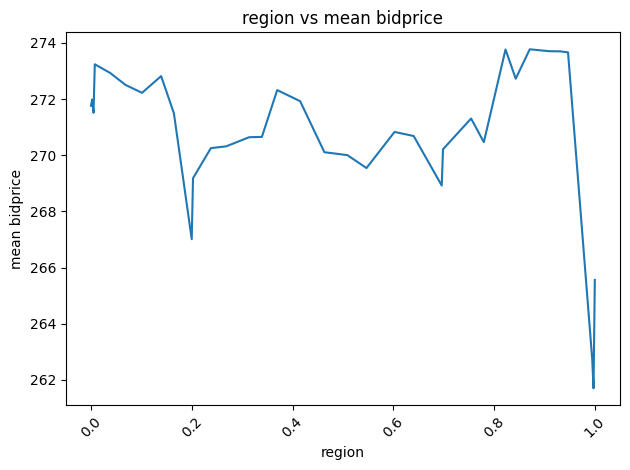

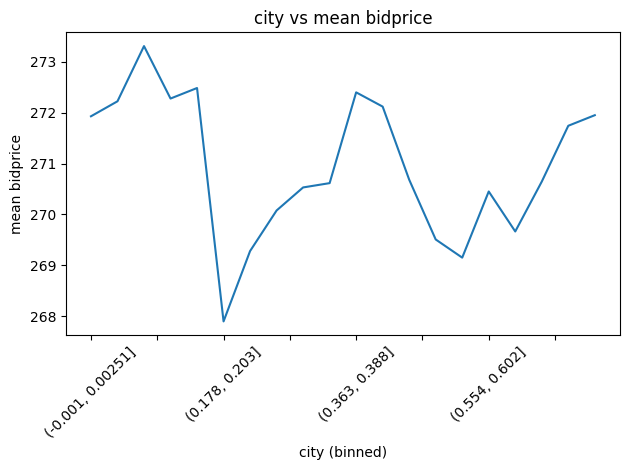

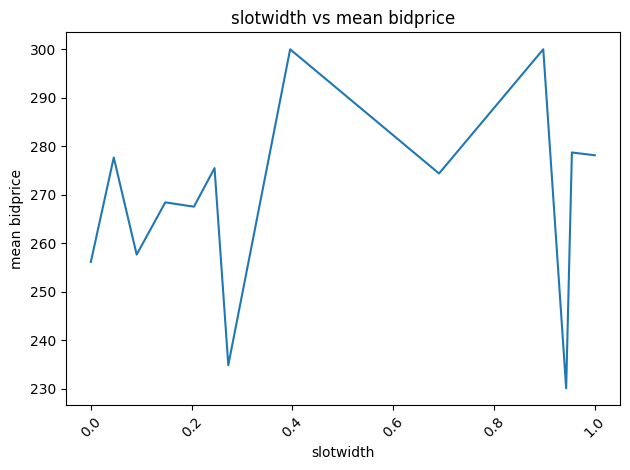

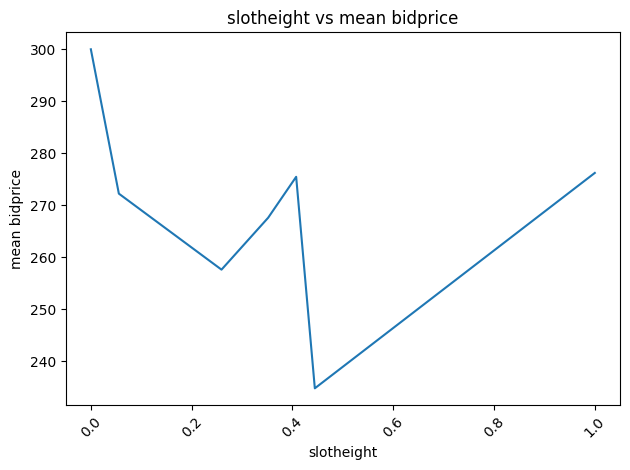

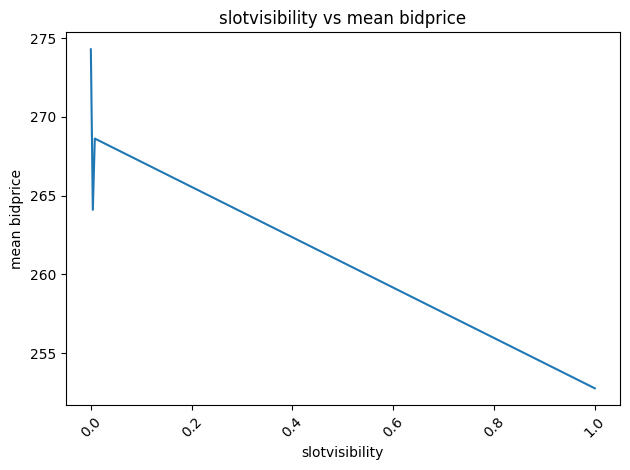

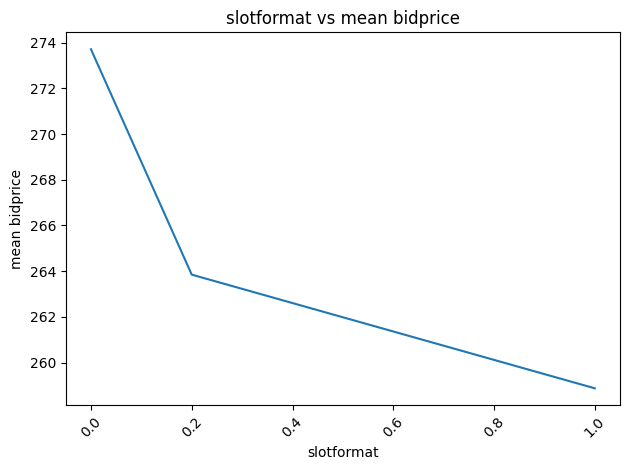

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

target = 'bidprice'

for col in df.columns:
    if col == target:
        continue

    plt.figure()

    # Nếu là numeric continuous → bin
    if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 50:
        binned = pd.qcut(df[col], q=20, duplicates='drop')
        agg = df.groupby(binned)[target].mean()
        agg.plot()
        plt.xlabel(f'{col} (binned)')
    
    else:
        agg = df.groupby(col)[target].mean()
        agg.plot()
        plt.xlabel(col)

    plt.ylabel(f'mean {target}')
    plt.title(f'{col} vs mean {target}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_split = df.copy()

# Chọn feature quan trọng để giữ distribution
df_split['stratify_key'] = (
    df_split['slotformat'].astype(str) + "_" +
    df_split['region'].astype(str)
)

# Những class quá ít sẽ gây lỗi stratify
value_counts = df_split['stratify_key'].value_counts()

rare_keys = value_counts[value_counts < 10].index

df_split.loc[df_split['stratify_key'].isin(rare_keys), 'stratify_key'] = 'rare'


train_val, test = train_test_split(
    df_split,
    test_size=0.15,
    stratify=df_split['stratify_key'],
    random_state=42
)

train, val = train_test_split(
    train_val,
    test_size=0.176,  # ~15% tổng dataset
    stratify=train_val['stratify_key'],
    random_state=42
)

train = train.sample(frac=1, random_state=42).reset_index(drop=True)


for d in [train, val, test]:
    d.drop(columns=['stratify_key'], inplace=True)

print(f"Train size: {len(train)}")
print(f"Val size:   {len(val)}")
print(f"Test size:  {len(test)}")

Train size: 1264889
Val size:   270171
Test size:  270893


In [21]:
train.to_csv('train_data.csv', index=False)
val.to_csv('val_data.csv', index=False)
test.to_csv('test_data.csv', index=False)

<Axes: >

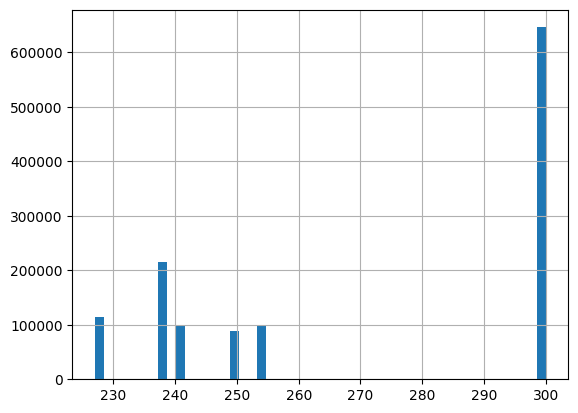

In [22]:
train['bidprice'].hist(bins=50)

<Axes: >

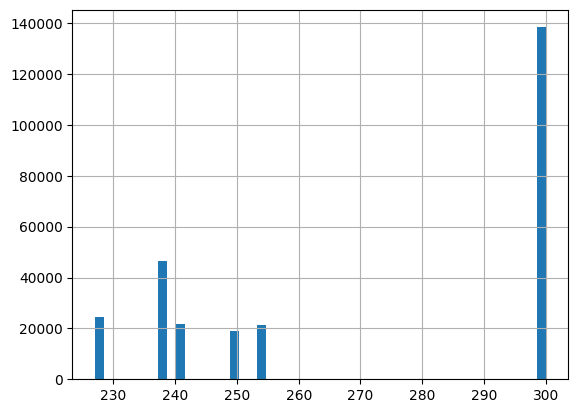

In [23]:
test['bidprice'].hist(bins=50)


<Axes: >

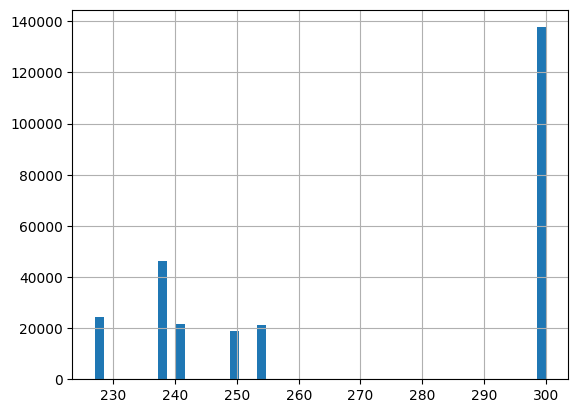

In [24]:
val['bidprice'].hist(bins=50)

## Tương quan - giảm chiều

In [25]:
# # target
# target = 'bidprice'

# # tính spearman correlation
# corr = df.corr(method='spearman')[target].sort_values(ascending=False)

# print(corr)

In [26]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import LabelEncoder

# # ======================
# # 1. LOAD DATA
# # ======================
# df = pd.read_csv("data_train.csv")

# # ======================
# # 2. CLEAN DATA
# # ======================

# # convert numeric
# num_cols = ['bidprice', 'payprice', 'slotprice', 'click', 'weekday', 'hour', 'slotwidth', 'slotheight', 'logtype']
# df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# # drop null quan trọng
# df = df.dropna(subset=['bidprice'])

# # scale (không bắt buộc cho Spearman, nhưng giữ cho sạch)
# df['bidprice'] = df['bidprice'] / 1000
# df['payprice'] = df['payprice'] / 1000
# df['slotprice'] = df['slotprice'] / 1000

# # ======================
# # 3. FEATURE ENGINEERING
# # ======================

# # peak hour
# df['is_peak'] = df['hour'].apply(lambda x: 1 if 8 <= x <= 22 else 0)

# # slot area (feature quan trọng hơn width/height riêng lẻ)
# df['slot_area'] = df['slotwidth'] * df['slotheight']

# # xử lý useragent (KHÔNG one-hot)
# df['useragent'] = df['useragent'].fillna('unknown').astype(str)

# # ======================
# # 4. DROP COLUMNS KHÔNG HỮU ÍCH
# # ======================

# drop_cols = ['timestamp']

# df = df.drop(columns=drop_cols, errors='ignore')

# # ======================
# # 5. ENCODE CATEGORICAL
# # ======================

# categorical_cols = df.select_dtypes(include=['object']).columns

# for col in categorical_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])

# df.head()

In [27]:
df.dtypes

hour              float64
region            float64
city              float64
slotwidth         float64
slotheight        float64
slotvisibility    float64
slotformat        float64
bidprice          float64
dtype: object

In [28]:
# # ======================
# # 6. SPEARMAN CORRELATION
# # ======================

# target = 'bidprice'

# corr = df.corr(method='spearman')[target].sort_values(ascending=False)

# print("=== Spearman Correlation với bidprice ===")
# print(corr)

# # ======================
# # 7. FEATURE SELECTION
# # ======================

# threshold = 0.05
# selected_features = corr[abs(corr) > threshold].index.tolist()

# # bỏ target khỏi list
# selected_features.remove(target)

# print("\n=== Selected Features (|corr| > 0.05) ===")
# print(selected_features)

In [29]:
# df.nunique()

## Mô tả bộ dữ liệu

- Mỗi bản ghi chứa ba loại thông tin: 
    - Đặc trưng đấu giá và quảng cáo (tất cả các cột ngoại trừ 3, 20 và 21). Các đặc trưng này được gửi đến công cụ đấu thầu để đưa ra phản hồi thầu.
    - Giá thắng thầu (cột 21), tức là giá thầu cao nhất từ các đối thủ cạnh tranh. Nếu công cụ đấu thầu phản hồi một mức giá thầu cao hơn giá thắng đấu giá, DSP sẽ thắng cuộc đấu giá này và nhận được lượt hiển thị quảng cáo. 
    - Phản hồi của người dùng (nhấp chuột và chuyển đổi) trên lượt hiển thị quảng cáo (cột 3).

- Một dòng trong data = một lần đấu giá thắng quảng cáo mà một DSP tham gia, gồm context + giá bid của nó + giá phải trả + giá sàn + kết quả thắng thua.

| Col # | Description              | Diễn giải |
|------|--------------------------|----------|
| 1    | Bid ID                  | Mã định danh duy nhất cho tất cả các nhật ký sự kiện; dùng để nối bid, impression, click, conversion |
| 2    | Timestamp               | Định dạng thời gian: yyyyMMddHHmmssSSS |
| 3    | Log type               | 1: hiển thị, 2: nhấp chuột, 3: chuyển đổi |
| 4    | iPinYou ID             | ID người dùng nội bộ do iPinYou thiết lập |
| 5    | User-Agent             | Mô tả thiết bị, hệ điều hành và trình duyệt của người dùng |
| 6    | IP                     | Địa chỉ IP của người dùng |
| 7    | Region                 | Mã khu vực |
| 8    | City                   | Mã thành phố |
| 9    | Ad exchange            | Sàn giao dịch quảng cáo |
| 10   | Domain                 | Tên miền trang web chứa quảng cáo (đã được băm) |
| 11   | URL                    | URL trang web chứa quảng cáo (đã được băm) |
| 12   | Anonymous URL ID       | Dùng khi URL không có sẵn; do ad exchange cung cấp |
| 13   | Ad slot ID             | ID vị trí quảng cáo |
| 14   | Ad slot width          | Chiều rộng vị trí quảng cáo |
| 15   | Ad slot height         | Chiều cao vị trí quảng cáo |
| 16   | Ad slot visibility     | Vị trí hiển thị: FirstView, SecondView... hoặc Na |
| 17   | Ad slot format         | Fixed, Pop, Background, Float hoặc Na |
| 18   | Ad slot floor price    | Giá sàn; bid thấp hơn sẽ không thắng; đã chuẩn hóa |
| 19   | Creative ID            | ID nội dung quảng cáo |
| 20   | Bidding price          | Giá thầu từ iPinYou |
| 21   | Paying price           | Giá thanh toán (giá thị trường/giá thắng) |
| 22   | Key page URL           | URL chính của trang (đã băm) |
| 23   | Advertiser ID          | ID nhà quảng cáo |
| 24   | User Tags              | Thẻ người dùng (segment), chỉ cung cấp một phần |